In [1]:
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

ALLEN_CACHE_DIR = (
    Path.home() /
    "allen_visual_behavior_neuropixels_cache"
)

NWB_PATH = max(
    ALLEN_CACHE_DIR.rglob("*.nwb"),
    key=lambda path: path.stat().st_size
)

OUTPUT_TABLE_DIR = Path("outputs/tables")
OUTPUT_FIGURE_DIR = Path("outputs/figures")

OUTPUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("NWB:", NWB_PATH.name)
print(f"Size: {NWB_PATH.stat().st_size / 1024**3:.2f} GB")

NWB: ecephys_session_1119946360.nwb
Size: 3.40 GB


In [2]:
with h5py.File(NWB_PATH, "r") as h5_file:
    units_group = h5_file["units"]

    print("Unit-table datasets:")
    print(list(units_group.keys()))

    print("\nUnit-table attributes:")
    print(dict(units_group.attrs))

    print("\nDataset shapes:")
    for name, item in units_group.items():
        if isinstance(item, h5py.Dataset):
            print(
                f"{name:35s} "
                f"shape={item.shape}, dtype={item.dtype}"
            )

Unit-table datasets:
['PT_ratio', 'amplitude', 'amplitude_cutoff', 'cluster_id', 'cumulative_drift', 'd_prime', 'firing_rate', 'id', 'isi_violations', 'isolation_distance', 'l_ratio', 'local_index', 'max_drift', 'nn_hit_rate', 'nn_miss_rate', 'peak_channel_id', 'presence_ratio', 'quality', 'recovery_slope', 'repolarization_slope', 'silhouette_score', 'snr', 'spike_amplitudes', 'spike_amplitudes_index', 'spike_times', 'spike_times_index', 'spread', 'velocity_above', 'velocity_below', 'waveform_duration', 'waveform_mean', 'waveform_mean_index']

Unit-table attributes:
{'colnames': array(['PT_ratio', 'amplitude', 'amplitude_cutoff', 'cluster_id',
       'cumulative_drift', 'd_prime', 'firing_rate', 'isi_violations',
       'isolation_distance', 'l_ratio', 'local_index', 'max_drift',
       'nn_hit_rate', 'nn_miss_rate', 'peak_channel_id', 'presence_ratio',
       'quality', 'recovery_slope', 'repolarization_slope',
       'silhouette_score', 'snr', 'spread', 'velocity_above',
       'velo

In [3]:
with h5py.File(NWB_PATH, "r") as h5_file:
    print("Top-level groups:")
    print(list(h5_file.keys()))

    print("\nGeneral subgroups:")
    print(list(h5_file["general"].keys()))

    if "extracellular_ephys" in h5_file["general"]:
        print("\nExtracellular-ephys subgroups:")
        print(
            list(
                h5_file["general"]["extracellular_ephys"].keys()
            )
        )

Top-level groups:
['acquisition', 'analysis', 'file_create_date', 'general', 'identifier', 'intervals', 'processing', 'session_description', 'session_start_time', 'specifications', 'stimulus', 'timestamps_reference_time', 'units']

General subgroups:
['devices', 'extracellular_ephys', 'institution', 'keywords', 'metadata', 'subject', 'task_parameters']

Extracellular-ephys subgroups:
['electrodes', 'probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']


In [4]:
def find_groups_with_name(h5_group, target_name):
    matches = []

    def visitor(name, obj):
        if isinstance(obj, h5py.Group):
            if target_name.lower() in name.lower():
                matches.append(name)

    h5_group.visititems(visitor)
    return matches


with h5py.File(NWB_PATH, "r") as h5_file:
    for target in ["electrode", "channel", "probe"]:
        matches = find_groups_with_name(h5_file, target)

        print(f"\nGroups containing '{target}':")
        for match in matches:
            print(" -", match)


Groups containing 'electrode':
 - general/extracellular_ephys/electrodes

Groups containing 'channel':

Groups containing 'probe':
 - general/devices/probeA
 - general/devices/probeB
 - general/devices/probeC
 - general/devices/probeD
 - general/devices/probeE
 - general/devices/probeF
 - general/extracellular_ephys/probeA
 - general/extracellular_ephys/probeB
 - general/extracellular_ephys/probeC
 - general/extracellular_ephys/probeD
 - general/extracellular_ephys/probeE
 - general/extracellular_ephys/probeF


In [5]:
ELECTRODE_GROUP_PATH = "general/extracellular_ephys/electrodes"

with h5py.File(NWB_PATH, "r") as h5_file:
    electrode_group = h5_file[ELECTRODE_GROUP_PATH]

    print("Electrode-table datasets:")
    print(list(electrode_group.keys()))

    print("\nElectrode-table attributes:")
    print(dict(electrode_group.attrs))

    print("\nDataset shapes and types:")
    for name, item in electrode_group.items():
        if isinstance(item, h5py.Dataset):
            print(
                f"{name:40s} "
                f"shape={item.shape}, dtype={item.dtype}"
            )

Electrode-table datasets:
['filtering', 'group', 'group_name', 'id', 'imp', 'location', 'probe_channel_number', 'probe_horizontal_position', 'probe_id', 'probe_vertical_position', 'valid_data', 'x', 'y', 'z']

Electrode-table attributes:
{'colnames': array(['location', 'group', 'group_name', 'probe_vertical_position',
       'probe_horizontal_position', 'probe_id', 'probe_channel_number',
       'valid_data', 'x', 'y', 'z', 'imp', 'filtering'], dtype=object), 'description': 'metadata about extracellular electrodes', 'namespace': 'hdmf-common', 'neurodata_type': 'DynamicTable', 'object_id': '362ac813-3797-47ac-a1bc-a2dda7835981'}

Dataset shapes and types:
filtering                                shape=(2304,), dtype=object
group                                    shape=(2304,), dtype=object
group_name                               shape=(2304,), dtype=object
id                                       shape=(2304,), dtype=int64
imp                                      shape=(2304,), dtype

In [7]:
def decode_text(values):
    return np.array([
        value.decode("utf-8") if isinstance(value, bytes) else str(value)
        for value in values
    ])

with h5py.File(NWB_PATH, "r") as h5_file:
    units_group = h5_file["units"]
    electrodes_group = h5_file[
        "general/extracellular_ephys/electrodes"
    ]

    electrode_table = pd.DataFrame({
        "peak_channel_id": electrodes_group["id"][:],
        "structure": decode_text(
            electrodes_group["location"][:]
        ),
        "probe_id": electrodes_group["probe_id"][:],
        "probe_channel_number": (
            electrodes_group["probe_channel_number"][:]
        ),
        "valid_channel": electrodes_group["valid_data"][:].astype(int),
        "x": electrodes_group["x"][:],
        "y": electrodes_group["y"][:],
        "z": electrodes_group["z"][:]
    })

    unit_metadata = pd.DataFrame({
        "unit_id": units_group["id"][:],
        "cluster_id": units_group["cluster_id"][:],
        "peak_channel_id": units_group["peak_channel_id"][:],
        "quality": decode_text(units_group["quality"][:]),
        "firing_rate_hz": units_group["firing_rate"][:],
        "presence_ratio": units_group["presence_ratio"][:],
        "isi_violations": units_group["isi_violations"][:],
        "amplitude_cutoff": units_group["amplitude_cutoff"][:],
        "snr": units_group["snr"][:],
        "amplitude": units_group["amplitude"][:],
        "isolation_distance": units_group[
            "isolation_distance"
        ][:],
        "d_prime_quality": units_group["d_prime"][:]
    })

unit_metadata = unit_metadata.merge(
    electrode_table,
    on="peak_channel_id",
    how="left",
    validate="many_to_one"
)

print("Total units:", len(unit_metadata))
print("Units without an electrode-location match:",
      unit_metadata["structure"].isna().sum())

print("\nQuality labels:")
print(unit_metadata["quality"].value_counts(dropna=False))

print("\nMost common structures:")
print(unit_metadata["structure"].value_counts().head(25))

display(unit_metadata.head())

unit_metadata.to_csv(
    OUTPUT_TABLE_DIR / "allen_all_unit_metadata.csv",
    index=False
)

Total units: 3388
Units without an electrode-location match: 0

Quality labels:
good     2825
noise     563
Name: quality, dtype: int64

Most common structures:
CA1      641
MGv      314
DG       244
VISam    235
VISpm    216
VISal    197
VISp     197
VISl     193
VISrl    185
CA3      145
PIL      140
MGm      138
APN      119
POL      103
SUB       92
LGd       68
MGd       49
ProS      34
LP        30
root      19
PP        16
MB         9
TH         3
PRE        1
Name: structure, dtype: int64


,unit_id,cluster_id,peak_channel_id,quality,firing_rate_hz,presence_ratio,isi_violations,amplitude_cutoff,snr,amplitude,isolation_distance,d_prime_quality,structure,probe_id,probe_channel_number,valid_channel,x,y,z
0,1126282908,470,1126276729,good,0.046296,0.92,0.000000,0.029150,6.213603,579.452962,101.903710,11.647032,DG,1120165512,119,1,8099.0,2340.0,7432.0
1,1126282140,118,1126276729,good,0.036888,0.88,58.227481,0.254640,2.499634,164.454563,37.541417,6.071235,DG,1120165512,119,1,8099.0,2340.0,7432.0
2,1126283142,564,1126277061,noise,0.838922,0.99,0.056291,0.003587,2.853033,127.455607,51.755805,6.249952,VISam,1120165512,262,1,7712.0,622.0,7460.0
3,1126283139,563,1126277061,noise,0.073143,0.91,0.000000,0.000374,5.618318,270.045835,80.904329,10.520422,VISam,1120165512,262,1,7712.0,622.0,7460.0
4,1126283137,562,1126277061,good,0.517918,0.99,0.147692,0.005428,5.567714,342.144660,194.369564,11.843228,VISam,1120165512,262,1,7712.0,622.0,7460.0


In [8]:
unit_metadata["passes_allen_qc"] = (
    (unit_metadata["presence_ratio"] > 0.90)
    & (unit_metadata["isi_violations"] < 0.50)
    & (unit_metadata["amplitude_cutoff"] < 0.10)
)

visp_units_all = unit_metadata[
    unit_metadata["structure"] == "VISp"
].copy()

visp_units_qc = unit_metadata[
    (unit_metadata["structure"] == "VISp")
    & (unit_metadata["passes_allen_qc"])
].copy()

print("All VISp units:", len(visp_units_all))
print("QC-passing VISp units:", len(visp_units_qc))

print("\nQC-pass count by Allen quality label:")
print(
    visp_units_all
    .groupby("quality")["passes_allen_qc"]
    .agg(["sum", "count", "mean"])
)

print("\nQC-passing VISp firing-rate summary:")
print(
    visp_units_qc["firing_rate_hz"]
    .describe()
)

display(
    visp_units_qc[
        [
            "unit_id",
            "peak_channel_id",
            "probe_id",
            "quality",
            "firing_rate_hz",
            "presence_ratio",
            "isi_violations",
            "amplitude_cutoff",
            "snr"
        ]
    ].head()
)

visp_units_qc.to_csv(
    OUTPUT_TABLE_DIR / "allen_visp_units_qc.csv",
    index=False
)

All VISp units: 197
QC-passing VISp units: 117

QC-pass count by Allen quality label:
         sum  count      mean
quality                      
good     106    173  0.612717
noise     11     24  0.458333

QC-passing VISp firing-rate summary:
count    117.000000
mean       5.498055
std        7.476209
min        0.036043
25%        0.801401
50%        2.412871
75%        7.228782
max       53.528669
Name: firing_rate_hz, dtype: float64


,unit_id,peak_channel_id,probe_id,quality,firing_rate_hz,presence_ratio,isi_violations,amplitude_cutoff,snr
1137,1126285149,1126279025,1120165515,good,5.911470,0.99,0.000000,0.000448,5.607461
1147,1126285224,1126279071,1120165515,noise,0.349437,0.98,0.000000,0.000078,6.479418
1167,1126285145,1126279018,1120165515,good,2.813994,0.99,0.005003,0.001610,5.015975
1168,1126285081,1126278945,1120165515,good,17.410550,0.99,0.007188,0.029115,2.657656
1169,1126285080,1126278945,1120165515,noise,16.192488,0.99,0.005893,0.003099,4.248493


In [9]:
trial_csv_candidates = list(
    Path.cwd().rglob("allen_mouse_trials_raw.csv")
)

if not trial_csv_candidates:
    trial_csv_candidates = list(
        Path.home().rglob("allen_mouse_trials_raw.csv")
    )

print("Found trial-table files:")
for candidate in trial_csv_candidates:
    print(candidate)

Found trial-table files:
C:\Users\parsa\outputs\tables\allen_mouse_trials_raw.csv


In [10]:
MOUSE_TRIALS_PATH = trial_csv_candidates[0]

mouse_trials = pd.read_csv(MOUSE_TRIALS_PATH)

valid_trials = mouse_trials[
    (mouse_trials["aborted"] == 0)
    & (mouse_trials["auto_rewarded"] == 0)
].copy()

hit_trials = valid_trials[
    valid_trials["outcome"] == "hit"
].copy()

miss_trials = valid_trials[
    valid_trials["outcome"] == "miss"
].copy()

print("Valid trials:", len(valid_trials))
print("Hit trials:", len(hit_trials))
print("Miss trials:", len(miss_trials))

print("\nMissing change times:")
print(
    valid_trials.groupby("outcome")["change_time"]
    .apply(lambda values: values.isna().sum())
)

Valid trials: 251
Hit trials: 135
Miss trials: 86

Missing change times:
outcome
correct_rejection    0
false_alarm          0
hit                  0
miss                 0
Name: change_time, dtype: int64


In [11]:
visp_units_primary = visp_units_qc[
    visp_units_qc["quality"] == "good"
].copy()

print("Primary VISp unit set:", len(visp_units_primary))
print(
    "Unique probes:",
    sorted(visp_units_primary["probe_id"].unique())
)

display(
    visp_units_primary[
        [
            "unit_id",
            "peak_channel_id",
            "probe_id",
            "firing_rate_hz",
            "presence_ratio",
            "isi_violations",
            "amplitude_cutoff",
            "snr"
        ]
    ].head()
)

Primary VISp unit set: 106
Unique probes: [1120165515]


,unit_id,peak_channel_id,probe_id,firing_rate_hz,presence_ratio,isi_violations,amplitude_cutoff,snr
1137,1126285149,1126279025,1120165515,5.911470,0.99,0.000000,0.000448,5.607461
1167,1126285145,1126279018,1120165515,2.813994,0.99,0.005003,0.001610,5.015975
1168,1126285081,1126278945,1120165515,17.410550,0.99,0.007188,0.029115,2.657656
1172,1126285345,1126278970,1120165515,8.263775,0.99,0.014504,0.040648,2.601197
1173,1126285285,1126278970,1120165515,0.485893,0.95,0.000000,0.001675,4.162813


In [12]:
BASELINE_WINDOW = (-0.50, 0.00)
RESPONSE_WINDOW = (0.00, 0.50)

hit_change_times = hit_trials["change_time"].to_numpy()
miss_change_times = miss_trials["change_time"].to_numpy()

unit_id_to_row = {
    unit_id: row_index
    for row_index, unit_id in enumerate(
        unit_metadata["unit_id"].to_numpy()
    )
}

def count_spikes_in_windows(
    spike_times,
    event_times,
    window
):
    """
    Count sorted spikes for each event in one relative-time window.
    """
    window_start, window_end = window

    left_edges = event_times + window_start
    right_edges = event_times + window_end

    left_indices = np.searchsorted(
        spike_times,
        left_edges,
        side="left"
    )

    right_indices = np.searchsorted(
        spike_times,
        right_edges,
        side="left"
    )

    return right_indices - left_indices


spike_count_rows = []

with h5py.File(NWB_PATH, "r") as h5_file:
    units_group = h5_file["units"]

    spike_times_dataset = units_group["spike_times"]
    spike_index = units_group["spike_times_index"][:]

    for _, unit in visp_units_primary.iterrows():
        unit_id = int(unit["unit_id"])
        unit_row = unit_id_to_row[unit_id]

        start_index = (
            0 if unit_row == 0
            else int(spike_index[unit_row - 1])
        )

        end_index = int(spike_index[unit_row])

        unit_spike_times = spike_times_dataset[
            start_index:end_index
        ]

        for outcome_name, change_times in [
            ("hit", hit_change_times),
            ("miss", miss_change_times)
        ]:
            baseline_counts = count_spikes_in_windows(
                unit_spike_times,
                change_times,
                BASELINE_WINDOW
            )

            response_counts = count_spikes_in_windows(
                unit_spike_times,
                change_times,
                RESPONSE_WINDOW
            )

            for trial_number, (
                baseline_count,
                response_count
            ) in enumerate(
                zip(baseline_counts, response_counts)
            ):
                spike_count_rows.append({
                    "unit_id": unit_id,
                    "probe_id": int(unit["probe_id"]),
                    "structure": "VISp",
                    "outcome": outcome_name,
                    "outcome_trial_number": trial_number,
                    "baseline_spike_count": int(baseline_count),
                    "response_spike_count": int(response_count),
                    "baseline_rate_hz": (
                        baseline_count /
                        (BASELINE_WINDOW[1] - BASELINE_WINDOW[0])
                    ),
                    "response_rate_hz": (
                        response_count /
                        (RESPONSE_WINDOW[1] - RESPONSE_WINDOW[0])
                    )
                })

visp_hit_miss_spikes = pd.DataFrame(spike_count_rows)

print("Spike-count table shape:", visp_hit_miss_spikes.shape)
print("\nTrials per outcome:")
print(
    visp_hit_miss_spikes
    .groupby("outcome")["outcome_trial_number"]
    .nunique()
)

print("\nUnits per outcome:")
print(
    visp_hit_miss_spikes
    .groupby("outcome")["unit_id"]
    .nunique()
)

visp_hit_miss_spikes.to_csv(
    OUTPUT_TABLE_DIR / "allen_visp_hit_miss_spike_counts.csv",
    index=False
)

Spike-count table shape: (23426, 9)

Trials per outcome:
outcome
hit     135
miss     86
Name: outcome_trial_number, dtype: int64

Units per outcome:
outcome
hit     106
miss    106
Name: unit_id, dtype: int64


In [13]:
visp_unit_outcome_rates = (
    visp_hit_miss_spikes
    .groupby(["unit_id", "outcome"], as_index=False)
    .agg(
        mean_baseline_rate_hz=(
            "baseline_rate_hz",
            "mean"
        ),
        mean_response_rate_hz=(
            "response_rate_hz",
            "mean"
        ),
        n_trials=(
            "outcome_trial_number",
            "nunique"
        )
    )
)

visp_unit_outcome_rates["mean_evoked_rate_hz"] = (
    visp_unit_outcome_rates["mean_response_rate_hz"] -
    visp_unit_outcome_rates["mean_baseline_rate_hz"]
)

visp_unit_wide = (
    visp_unit_outcome_rates
    .pivot(
        index="unit_id",
        columns="outcome",
        values="mean_evoked_rate_hz"
    )
    .reset_index()
    .rename(
        columns={
            "hit": "hit_evoked_rate_hz",
            "miss": "miss_evoked_rate_hz"
        }
    )
)

visp_unit_wide["hit_minus_miss_hz"] = (
    visp_unit_wide["hit_evoked_rate_hz"] -
    visp_unit_wide["miss_evoked_rate_hz"]
)

print("Units with both hit and miss estimates:", len(visp_unit_wide))

print(
    visp_unit_wide[
        [
            "hit_evoked_rate_hz",
            "miss_evoked_rate_hz",
            "hit_minus_miss_hz"
        ]
    ].describe()
)

visp_unit_outcome_rates.to_csv(
    OUTPUT_TABLE_DIR / "allen_visp_unit_outcome_rates.csv",
    index=False
)

visp_unit_wide.to_csv(
    OUTPUT_TABLE_DIR / "allen_visp_hit_minus_miss_rates.csv",
    index=False
)

Units with both hit and miss estimates: 106
outcome  hit_evoked_rate_hz  miss_evoked_rate_hz  hit_minus_miss_hz
count            106.000000           106.000000         106.000000
mean               3.782110             2.182536           1.599574
std                6.863202             3.999644           3.481135
min               -8.977778            -3.837209          -5.675452
25%                0.222222             0.023256           0.052412
50%                1.740741             0.720930           0.491387
75%                5.044444             3.372093           2.258829
max               52.770370            27.953488          24.816882


In [14]:
from scipy.stats import wilcoxon

test_result = wilcoxon(
    visp_unit_wide["hit_evoked_rate_hz"],
    visp_unit_wide["miss_evoked_rate_hz"],
    alternative="two-sided"
)

mean_difference_hz = (
    visp_unit_wide["hit_minus_miss_hz"].mean()
)

median_difference_hz = (
    visp_unit_wide["hit_minus_miss_hz"].median()
)

print(f"Number of VISp units: {len(visp_unit_wide)}")
print(f"Mean hit-minus-miss difference: {mean_difference_hz:.3f} Hz")
print(f"Median hit-minus-miss difference: {median_difference_hz:.3f} Hz")
print(f"Wilcoxon statistic: {test_result.statistic:.1f}")
print(f"Wilcoxon p-value: {test_result.pvalue:.6g}")

Number of VISp units: 106
Mean hit-minus-miss difference: 1.600 Hz
Median hit-minus-miss difference: 0.491 Hz
Wilcoxon statistic: 943.0
Wilcoxon p-value: 2.44707e-09


C:\Users\parsa\AppData\Local\Temp\ipykernel_85372\1765182604.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


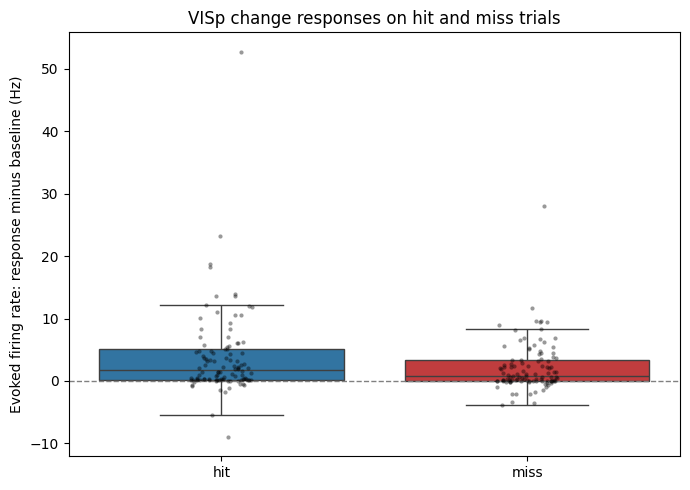

In [15]:
plot_rates = visp_unit_outcome_rates.copy()

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=plot_rates,
    x="outcome",
    y="mean_evoked_rate_hz",
    order=["hit", "miss"],
    palette={
        "hit": "#1f77b4",
        "miss": "#d62728"
    },
    showfliers=False
)

sns.stripplot(
    data=plot_rates,
    x="outcome",
    y="mean_evoked_rate_hz",
    order=["hit", "miss"],
    color="black",
    alpha=0.40,
    size=3
)

plt.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.xlabel("")
plt.ylabel("Evoked firing rate: response minus baseline (Hz)")
plt.title("VISp change responses on hit and miss trials")

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURE_DIR / "allen_visp_hit_vs_miss_evoked_rates.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

In [16]:
PETH_WINDOW = (-0.50, 0.75)
BIN_SIZE = 0.05

bin_edges = np.arange(
    PETH_WINDOW[0],
    PETH_WINDOW[1] + BIN_SIZE,
    BIN_SIZE
)

bin_centers = (
    bin_edges[:-1] +
    bin_edges[1:]
) / 2

peth_rows = []

with h5py.File(NWB_PATH, "r") as h5_file:
    units_group = h5_file["units"]

    spike_times_dataset = units_group["spike_times"]
    spike_index = units_group["spike_times_index"][:]

    for _, unit in visp_units_primary.iterrows():
        unit_id = int(unit["unit_id"])
        unit_row = unit_id_to_row[unit_id]

        start_index = (
            0 if unit_row == 0
            else int(spike_index[unit_row - 1])
        )

        end_index = int(spike_index[unit_row])

        spikes = spike_times_dataset[start_index:end_index]

        for outcome_name, event_times in [
            ("hit", hit_change_times),
            ("miss", miss_change_times)
        ]:
            relative_spikes = []

            for event_time in event_times:
                start = event_time + PETH_WINDOW[0]
                end = event_time + PETH_WINDOW[1]

                left = np.searchsorted(spikes, start, side="left")
                right = np.searchsorted(spikes, end, side="left")

                relative_spikes.append(
                    spikes[left:right] - event_time
                )

            if relative_spikes:
                relative_spikes = np.concatenate(relative_spikes)
            else:
                relative_spikes = np.array([])

            spike_counts, _ = np.histogram(
                relative_spikes,
                bins=bin_edges
            )

            rates_hz = (
                spike_counts /
                (len(event_times) * BIN_SIZE)
            )

            for time_s, rate_hz in zip(
                bin_centers,
                rates_hz
            ):
                peth_rows.append({
                    "unit_id": unit_id,
                    "outcome": outcome_name,
                    "time_from_change_s": time_s,
                    "rate_hz": rate_hz
                })

visp_peth = pd.DataFrame(peth_rows)

visp_peth.to_csv(
    OUTPUT_TABLE_DIR / "allen_visp_hit_miss_peth.csv",
    index=False
)

population_peth = (
    visp_peth
    .groupby(
        ["outcome", "time_from_change_s"],
        as_index=False
    )
    .agg(
        mean_rate_hz=("rate_hz", "mean"),
        sem_rate_hz=(
            "rate_hz",
            lambda values: values.std(ddof=1) / np.sqrt(len(values))
        ),
        n_units=("unit_id", "nunique")
    )
)

display(population_peth.head())

,outcome,time_from_change_s,mean_rate_hz,sem_rate_hz,n_units
0,hit,-0.475,6.331237,0.836138,106
1,hit,-0.425,8.116003,1.273676,106
2,hit,-0.375,2.703005,0.523701,106
3,hit,-0.325,1.404612,0.307692,106
4,hit,-0.275,2.413697,0.467221,106


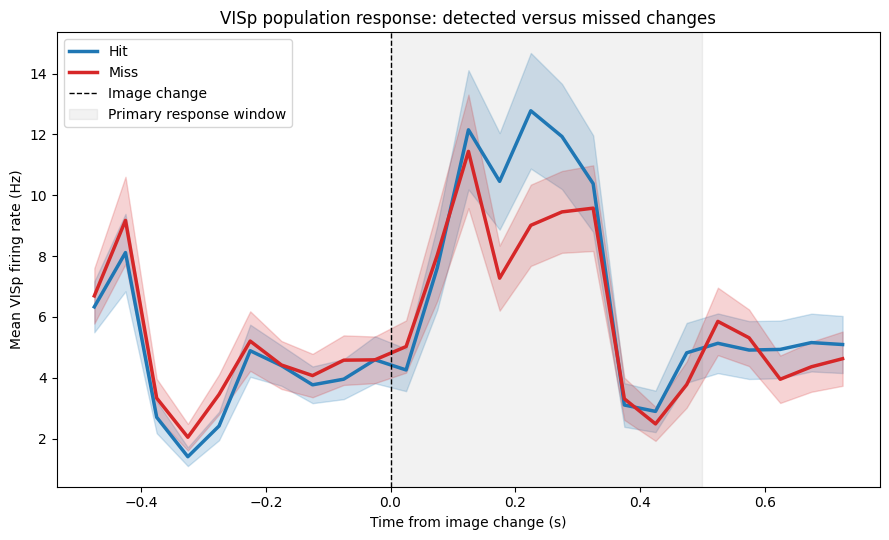

In [17]:
plt.figure(figsize=(9, 5.5))

colors = {
    "hit": "#1f77b4",
    "miss": "#d62728"
}

for outcome in ["hit", "miss"]:
    subset = population_peth[
        population_peth["outcome"] == outcome
    ]

    plt.plot(
        subset["time_from_change_s"],
        subset["mean_rate_hz"],
        label=outcome.capitalize(),
        color=colors[outcome],
        linewidth=2.5
    )

    plt.fill_between(
        subset["time_from_change_s"],
        subset["mean_rate_hz"] - subset["sem_rate_hz"],
        subset["mean_rate_hz"] + subset["sem_rate_hz"],
        color=colors[outcome],
        alpha=0.20
    )

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Image change"
)

plt.axvspan(
    0,
    0.50,
    color="gray",
    alpha=0.10,
    label="Primary response window"
)

plt.xlabel("Time from image change (s)")
plt.ylabel("Mean VISp firing rate (Hz)")
plt.title("VISp population response: detected versus missed changes")
plt.legend(frameon=True)
plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURE_DIR / "allen_visp_hit_miss_population_peth.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

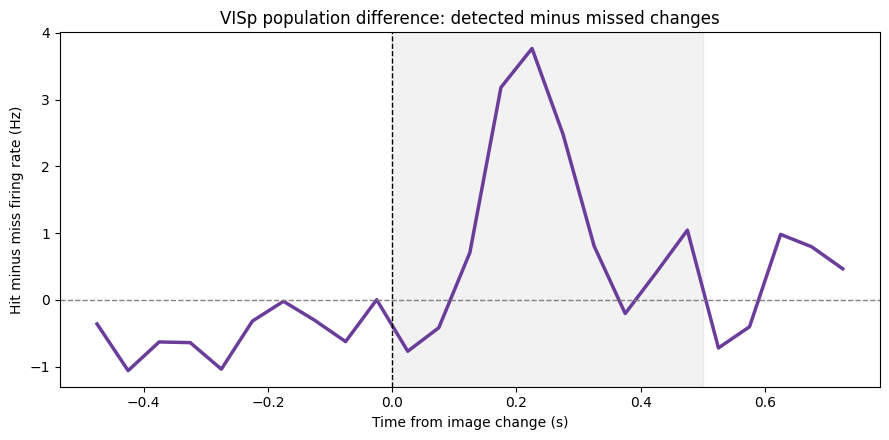

In [18]:
peth_wide = (
    population_peth
    .pivot(
        index="time_from_change_s",
        columns="outcome",
        values="mean_rate_hz"
    )
    .reset_index()
)

peth_wide["hit_minus_miss_hz"] = (
    peth_wide["hit"] - peth_wide["miss"]
)

peth_wide.to_csv(
    OUTPUT_TABLE_DIR / "allen_visp_hit_minus_miss_peth.csv",
    index=False
)

plt.figure(figsize=(9, 4.5))

plt.plot(
    peth_wide["time_from_change_s"],
    peth_wide["hit_minus_miss_hz"],
    color="#6a3d9a",
    linewidth=2.5
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.axvspan(0, 0.50, color="gray", alpha=0.10)

plt.xlabel("Time from image change (s)")
plt.ylabel("Hit minus miss firing rate (Hz)")
plt.title("VISp population difference: detected minus missed changes")

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURE_DIR / "allen_visp_hit_minus_miss_peth.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix
)
from scipy.stats import binomtest
import numpy as np
import pandas as pd

PRIMARY_WINDOW_S = 0.50

decode_data = visp_hit_miss_spikes.copy()

# Preserve outcome-specific trial identity, then pivot to:
# rows = trials, columns = VISp units, values = spike counts
trial_neuron_counts = (
    decode_data
    .pivot(
        index=["outcome", "outcome_trial_number"],
        columns="unit_id",
        values="response_spike_count"
    )
    .reset_index()
)

trial_labels = (
    trial_neuron_counts["outcome"]
    .eq("hit")
    .astype(int)
    .to_numpy()
)

X_counts = (
    trial_neuron_counts
    .drop(columns=["outcome", "outcome_trial_number"])
    .to_numpy()
)

unit_ids = (
    trial_neuron_counts
    .drop(columns=["outcome", "outcome_trial_number"])
    .columns
    .to_numpy()
)

print("Feature matrix shape (trials x units):", X_counts.shape)
print("Hit trials:", int(trial_labels.sum()))
print("Miss trials:", int((trial_labels == 0).sum()))
print("Units:", len(unit_ids))
print("Any missing values?", np.isnan(X_counts).any())

Feature matrix shape (trials x units): (221, 106)
Hit trials: 135
Miss trials: 86
Units: 106
Any missing values? False


In [20]:
N_SPLITS = 5
N_REPEATS = 20
RANDOM_SEED = 42

cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_SEED
)

decoder = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        max_iter=5000,
        random_state=RANDOM_SEED
    ))
])

cv_rows = []

for split_number, (train_index, test_index) in enumerate(
    cv.split(X_counts, trial_labels),
    start=1
):
    X_train = X_counts[train_index]
    X_test = X_counts[test_index]

    y_train = trial_labels[train_index]
    y_test = trial_labels[test_index]

    decoder.fit(X_train, y_train)

    predicted_labels = decoder.predict(X_test)
    predicted_probabilities = decoder.predict_proba(X_test)[:, 1]

    cv_rows.append({
        "split": split_number,
        "accuracy": accuracy_score(y_test, predicted_labels),
        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            predicted_labels
        ),
        "roc_auc": roc_auc_score(
            y_test,
            predicted_probabilities
        ),
        "n_test_trials": len(test_index),
        "n_test_hits": int(y_test.sum()),
        "n_test_misses": int((y_test == 0).sum())
    })

decoder_cv_results = pd.DataFrame(cv_rows)

print(
    decoder_cv_results[
        ["accuracy", "balanced_accuracy", "roc_auc"]
    ].describe()
)

decoder_cv_results.to_csv(
    OUTPUT_TABLE_DIR / "allen_visp_hit_miss_decoder_cv.csv",
    index=False
)

         accuracy  balanced_accuracy     roc_auc
count  100.000000         100.000000  100.000000
mean     0.755424           0.743856    0.809742
std      0.065331           0.070628    0.061783
min      0.500000           0.483660    0.529412
25%      0.727273           0.703976    0.778807
50%      0.750000           0.749455    0.811668
75%      0.796591           0.796296    0.848584
max      0.886364           0.877996    0.934641


In [21]:
mean_accuracy = decoder_cv_results["accuracy"].mean()
mean_balanced_accuracy = (
    decoder_cv_results["balanced_accuracy"].mean()
)
mean_auc = decoder_cv_results["roc_auc"].mean()

print(f"Mean accuracy: {mean_accuracy:.3f}")
print(
    "Mean balanced accuracy: "
    f"{mean_balanced_accuracy:.3f}"
)
print(f"Mean ROC-AUC: {mean_auc:.3f}")
print(
    "Balanced-accuracy range across CV splits: "
    f"{decoder_cv_results['balanced_accuracy'].min():.3f} to "
    f"{decoder_cv_results['balanced_accuracy'].max():.3f}"
)

Mean accuracy: 0.755
Mean balanced accuracy: 0.744
Mean ROC-AUC: 0.810
Balanced-accuracy range across CV splits: 0.484 to 0.878


In [22]:
N_PERMUTATIONS = 200
permutation_scores = []

for permutation_number in range(N_PERMUTATIONS):
    shuffled_labels = rng.permutation(trial_labels)

    split_scores = []

    for train_index, test_index in cv.split(X_counts, shuffled_labels):
        decoder.fit(
            X_counts[train_index],
            shuffled_labels[train_index]
        )

        shuffled_predictions = decoder.predict(
            X_counts[test_index]
        )

        split_scores.append(
            balanced_accuracy_score(
                shuffled_labels[test_index],
                shuffled_predictions
            )
        )

    permutation_scores.append(np.mean(split_scores))

permutation_scores = np.array(permutation_scores)

permutation_p_value = (
    1 + np.sum(permutation_scores >= mean_balanced_accuracy)
) / (N_PERMUTATIONS + 1)

print(
    "Observed mean balanced accuracy: "
    f"{mean_balanced_accuracy:.3f}"
)
print(
    "Permutation mean balanced accuracy: "
    f"{permutation_scores.mean():.3f}"
)
print(
    "Permutation p-value: "
    f"{permutation_p_value:.4f}"
)

pd.DataFrame({
    "permutation_balanced_accuracy": permutation_scores
}).to_csv(
    OUTPUT_TABLE_DIR / "allen_visp_decoder_permutation_scores.csv",
    index=False
)

Observed mean balanced accuracy: 0.744
Permutation mean balanced accuracy: 0.499
Permutation p-value: 0.0050


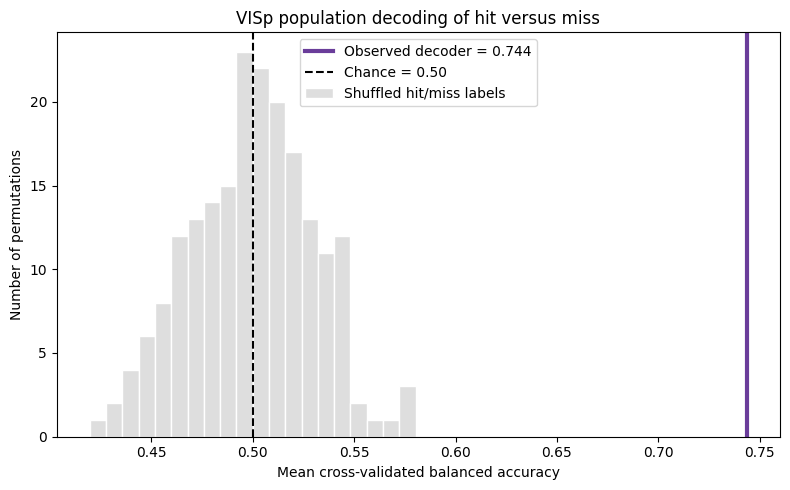

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    permutation_scores,
    bins=20,
    color="lightgray",
    edgecolor="white",
    label="Shuffled hit/miss labels"
)

plt.axvline(
    mean_balanced_accuracy,
    color="#6a3d9a",
    linewidth=3,
    label=(
        "Observed decoder = "
        f"{mean_balanced_accuracy:.3f}"
    )
)

plt.axvline(
    0.50,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Chance = 0.50"
)

plt.xlabel("Mean cross-validated balanced accuracy")
plt.ylabel("Number of permutations")
plt.title("VISp population decoding of hit versus miss")
plt.legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_FIGURE_DIR / "allen_visp_hit_miss_decoder_permutation.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

,analysis_domain,system,measure,value,unit,notes
0,Behavior,Moderate-noise GRU,Hit rate,0.798442,proportion,Original RNN threshold
1,Behavior,Mouse session 1119946360,Hit rate,0.610860,proportion,135 hits / 221 go trials
2,Behavior,Moderate-noise GRU,False-alarm rate,0.048744,proportion,Original RNN threshold
3,Behavior,Mouse session 1119946360,False-alarm rate,0.066667,proportion,2 false alarms / 30 catch trials
4,Behavior,Moderate-noise GRU,d_prime,2.491848,SDT units,Log-linear corrected rates
5,Behavior,Mouse session 1119946360,d_prime,1.681003,SDT units,Log-linear corrected rates
6,Behavior,Moderate-noise GRU,criterion,0.410122,SDT units,Positive means conservative
7,Behavior,Mouse session 1119946360,criterion,0.560243,SDT units,More conservative than RNN
8,Threshold matched,Moderate-noise GRU,Hit rate at mouse FA rate,0.818000,proportion,Threshold = 0.428; false-alarm rate = 0.067
9,Neural response,Mouse VISp,Hit minus miss evoked firing,1.599574,Hz,106 good QC-passing VISp units; 0-500 ms


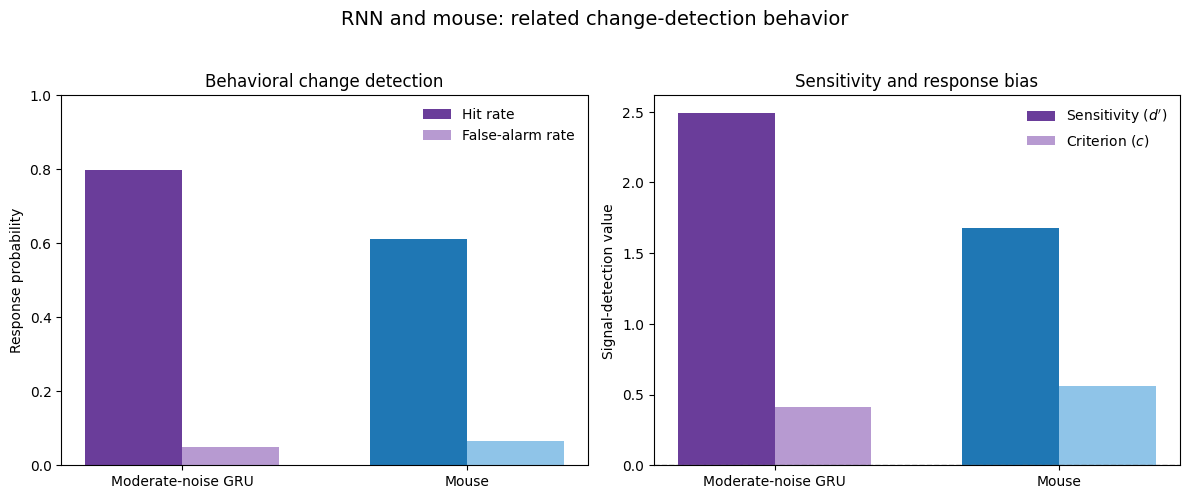